In [1]:
!pip show grad-cam

In [2]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
!pip install grad-cam -q
!pip install torch torchvision matplotlib pillow opencv-python -q

In [4]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn

from torchvision import transforms, models

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!git clone https://github.com/ankitha24ad002-boop/LungLens.git

Cloning into 'LungLens'...
remote: Enumerating objects: 175, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 175 (delta 55), reused 60 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (175/175), 577.69 KiB | 13.13 MiB/s, done.
Resolving deltas: 100% (55/55), done.


In [7]:
import sys
sys.path.append("/content/LungLens")

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=None)

model.fc = nn.Linear(model.fc.in_features,2)

model.load_state_dict(
    torch.load(
        "/content/LungLens/models/best_model.pth",
        map_location=device
    )
)

model.to(device)

model.eval()

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [13]:
with open("/content/LungLens/models/label_map.json", "r") as f:
    print(repr(f.read()))

'\n'


In [14]:
import json

label_map = {
    "0": "BACTERIA",
    "1": "VIRUS"
}

with open("/content/LungLens/models/label_map.json", "w") as f:
    json.dump(label_map, f, indent=4)

print("✅ label_map.json recreated successfully!")

✅ label_map.json recreated successfully!


In [15]:
with open("/content/LungLens/models/label_map.json", "r") as f:
    print(f.read())

{
    "0": "BACTERIA",
    "1": "VIRUS"
}


In [16]:
import json

with open("/content/LungLens/models/label_map.json", "r") as f:
    label_map = json.load(f)

print(label_map)

{'0': 'BACTERIA', '1': 'VIRUS'}


In [17]:
import os
import shutil

os.makedirs("/content/drive/MyDrive/LungLens/models", exist_ok=True)

shutil.copy(
    "/content/LungLens/models/label_map.json",
    "/content/drive/MyDrive/LungLens/models/label_map.json"
)

print("✅ label_map.json backed up to Google Drive!")

✅ label_map.json backed up to Google Drive!


In [18]:
image_path = "/content/drive/MyDrive/LungLens/data/processed/train/BACTERIA/BACTERIA-7.jpeg"

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


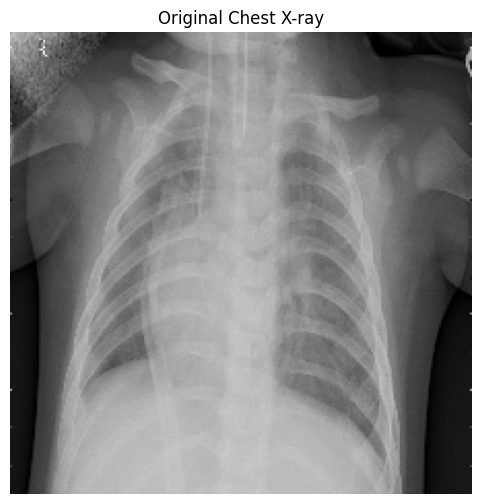

In [22]:
image_path = "/content/drive/MyDrive/LungLens/data/processed/test/BACTERIA/BACTERIA-11.jpeg"

from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Original Chest X-ray")
plt.axis("off")
plt.show()

In [23]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

input_tensor = transform(image).unsqueeze(0).to(device)

print(input_tensor.shape)

torch.Size([1, 3, 224, 224])


In [24]:
import torch

with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = torch.softmax(outputs, dim=1)

    confidence, predicted = torch.max(probabilities, 1)

prediction = label_map[str(predicted.item())]

print("Prediction:", prediction)
print("Confidence:", round(confidence.item(), 4))

Prediction: BACTERIA
Confidence: 0.5521


In [25]:
from pytorch_grad_cam import GradCAM

# Last convolutional layer of ResNet18
target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

print("✅ Grad-CAM initialized")

✅ Grad-CAM initialized


In [26]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

targets = [ClassifierOutputTarget(predicted.item())]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

print(grayscale_cam.shape)

(224, 224)


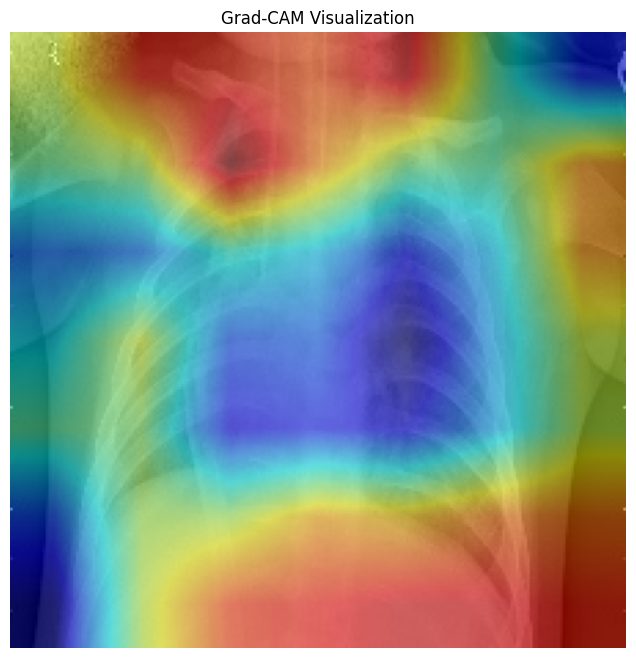

In [27]:
import numpy as np
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

rgb_image = np.array(
    image.resize((224, 224))
).astype(np.float32) / 255.0

visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))
plt.imshow(visualization)
plt.title("Grad-CAM Visualization")
plt.axis("off")
plt.show()

In [28]:
import os
import matplotlib.pyplot as plt

os.makedirs("/content/LungLens/results", exist_ok=True)

plt.imsave(
    "/content/LungLens/results/gradcam_result.png",
    visualization
)

print("✅ Grad-CAM image saved!")

✅ Grad-CAM image saved!


In [29]:
import shutil
import os

os.makedirs("/content/drive/MyDrive/LungLens/results", exist_ok=True)

shutil.copy(
    "/content/LungLens/results/gradcam_result.png",
    "/content/drive/MyDrive/LungLens/results/gradcam_result.png"
)

print("✅ Result copied to Google Drive!")

✅ Result copied to Google Drive!


In [30]:
from pytorch_grad_cam import GradCAM

# Last convolutional layer of ResNet18
target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

print("✅ Grad-CAM initialized")

✅ Grad-CAM initialized


In [31]:
import os
import matplotlib.pyplot as plt

os.makedirs("/content/LungLens/results", exist_ok=True)

plt.imsave(
    "/content/LungLens/results/gradcam_result.png",
    visualization
)

print("✅ Grad-CAM image saved.")

✅ Grad-CAM image saved.


In [32]:
import shutil
import os

# Create folders
os.makedirs("/content/drive/MyDrive/LungLens/models", exist_ok=True)
os.makedirs("/content/drive/MyDrive/LungLens/results", exist_ok=True)

# Copy trained model
shutil.copy(
    "/content/LungLens/models/best_model.pth",
    "/content/drive/MyDrive/LungLens/models/best_model.pth"
)

# Copy label map
shutil.copy(
    "/content/LungLens/models/label_map.json",
    "/content/drive/MyDrive/LungLens/models/label_map.json"
)

# Copy Grad-CAM image
shutil.copy(
    "/content/LungLens/results/gradcam_result.png",
    "/content/drive/MyDrive/LungLens/results/gradcam_result.png"
)

print("✅ All files copied to Google Drive!")

✅ All files copied to Google Drive!


In [33]:
from google.colab import files
files.download("/content/LungLens/models/best_model.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
files.download("/content/LungLens/models/label_map.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
files.download("/content/LungLens/results/gradcam_result.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>